# 04 · The segmentation shoot-out

One table, one chart, one winner. Reads the result files written by 01, 02 and 03 and picks the segmenter the rest of the pipeline will use.

---

> **Where this sits.** `00 setup` → stage 1 candidates `01 YOLO` · `02 SAM` · `03 Moondream` → `04 seg shoot-out` → `05 crop dataset` → stage 2 candidates `06 InceptionV3` · `07 MaxViT-tiny` · `08 ResNet50` · `09 MobileNet+SVM` · `10 QSVM` → `11 cls shoot-out` → `12 Grad-CAM` → `13 external set` → `14 end-to-end` → `15 gap`. Every stage reads the previous one's artefacts from `runs_two_stage/`, so this notebook runs on its own — it does **not** need the others to be open.

> **Needs first:** `01`, `02` and `03` (any subset that has been run)

### Bootstrap — environment, hardware profile, shared config

Identical in every notebook of this series. It detects where it is running
(**Colab/T4**, **IBEX/A100**, or local), turns on the right accelerations for that GPU, pins the
seed, and re-opens the shared `runs_two_stage/` folder so **any notebook can be run on its own** —
each stage reads the previous stage's artefacts from disk, not from memory.

**The A100 / T4 split is deliberate.** Only *throughput* knobs change with the GPU (batch size,
dataloader workers, AMP dtype, RAM caching, how many smears SAM pseudo-labels). *Capacity* knobs —
model size, image size, epochs — stay identical on both, so an A100 run and a T4 run remain
scientifically comparable. Every result file records the tier that produced it.

In [14]:
# ═════════════════════════════════════════════════════════════════════════════
#  SCD pipeline · shared bootstrap  (identical in every notebook of the series)
# ═════════════════════════════════════════════════════════════════════════════
import os, sys, re, glob, json, math, time, random, shutil, zipfile, warnings, subprocess


def _refresh_import_path():
    '''make what pip just installed visible to THIS interpreter, without a kernel restart.

    On managed images (Kaggle / Colab / IBEX) pip usually lands in the per-user site
    directory. If that directory did not exist when python started, site.py never put it
    on sys.path -- so a fresh install stays invisible until the kernel is restarted.
    Re-adding the install targets by hand is what removes the "restart and run all" step.
    '''
    import site, sysconfig, importlib
    cands = [sysconfig.get_path('purelib'), sysconfig.get_path('platlib')]
    for get in (site.getusersitepackages, site.getsitepackages):
        try:
            got = get()
            cands += [got] if isinstance(got, str) else list(got)
        except Exception:
            pass
    for d in cands:
        if d and os.path.isdir(d) and d not in sys.path:
            sys.path.append(d)                       # append: never shadow the image's own
            print('  + sys.path', d)
    importlib.invalidate_caches()
    sys.modules.pop('pkg_resources', None)           # its metadata cache is now stale


def _ensure(*pkgs):
    '''pip-install only what is genuinely missing -- IBEX compute nodes are often offline.

    No -U: these images pin a whole CUDA/numpy stack, and upgrading a transitive dep to
    satisfy a new package is how you break cudf/numba for the rest of the session.
    '''
    miss = [spec for mod, spec in pkgs if not _has(mod)]
    if not miss:
        return
    print('installing:', *miss)
    base = [sys.executable, '-m', 'pip', 'install', '-q']
    log = []
    for extra in ([], ['--user']):                   # plain first; --user if it stayed invisible
        r = subprocess.run(base + extra + list(miss), capture_output=True, text=True)
        log.append((extra, r.stdout, r.stderr))
        _refresh_import_path()
        miss = [spec for mod, spec in pkgs if not _has(mod)]
        if not miss:
            return
    for extra, out, err in log:                      # only reached when it truly failed
        print('--- pip', *extra, '---')
        print((out or '')[-1500:], (err or '')[-1500:], sep='')
    raise ImportError(
        'could not import after installing: ' + ', '.join(miss) +
        '\n  pip output is above. If it shows a successful install, restart the kernel'
        '\n  and re-run -- the packages are on disk but not on this process sys.path.'
        '\n  On an offline node, install them by hand first.')


def _has(mod):
    try:
        __import__(mod)
        return True
    except Exception:
        return False


# cv2 normally rides in with ultralytics, but an ultralytics that is already present
# (or a pip that could not reach the network) leaves no opencv behind -- ask for it.
_ensure(('cv2', 'opencv-python-headless'),
        ('ultralytics', 'ultralytics'), ('kagglehub', 'kagglehub'))

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── where are we? ────────────────────────────────────────────────────────────
if 'google.colab' in sys.modules:
    PLATFORM = 'colab'
elif os.environ.get('SLURM_JOB_ID') or os.path.isdir('/ibex'):
    PLATFORM = 'ibex'
else:
    PLATFORM = 'local'

# ── which GPU? ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEV = 'cuda'
    GPU = torch.cuda.get_device_name(0)
    CAP = torch.cuda.get_device_capability(0)
    VRAM = torch.cuda.get_device_properties(0).total_memory / 2 ** 30
else:
    DEV, GPU, CAP, VRAM = 'cpu', 'cpu', (0, 0), 0.0

TIER = 'a100' if (CAP[0] >= 8 and VRAM >= 30) else ('t4' if DEV == 'cuda' else 'cpu')

# bf16 has fp32's exponent range -> no GradScaler, no overflow. fp16 (T4) still needs the scaler.
AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16
USE_SCALER = (AMP_DTYPE == torch.float16) and DEV == 'cuda'

if CAP[0] >= 8:                      # Ampere+: ~2x on every fp32 matmul/conv, for free
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# throughput knobs ONLY -- see the markdown above for why capacity knobs are not in here
PROFILE = {
    'a100': dict(workers=8, prefetch=4, cls_batch=64, sam_embed_batch=8, sam_box_batch=32,
                 yolo_cache='ram', sam_points_bulk=32, sam_qc_smears=30, md_batch=8,
                 sam_max={'cuba_full': 200, 'uganda_clean': 200, 'uganda_neg': 100}),
    't4':   dict(workers=2, prefetch=2, cls_batch=32, sam_embed_batch=2, sam_box_batch=8,
                 yolo_cache=False, sam_points_bulk=24, sam_qc_smears=20, md_batch=2,
                 sam_max={'cuba_full': 60, 'uganda_clean': 60, 'uganda_neg': 30}),
    'cpu':  dict(workers=0, prefetch=2, cls_batch=8, sam_embed_batch=1, sam_box_batch=4,
                 yolo_cache=False, sam_points_bulk=16, sam_qc_smears=4, md_batch=1,
                 sam_max={'cuba_full': 6, 'uganda_clean': 6, 'uganda_neg': 3}),
}[TIER]

CFG = {
    # --- where things live (env vars win, so an sbatch script can set them) -------------------
    'data_root':  os.environ.get('SCD_DATA_ROOT', ''),
    'runs_dir':   os.environ.get('SCD_RUNS_DIR', ''),
    'drive_hints': ['/content/drive/MyDrive/SRSI_Final',
                    '/content/drive/MyDrive/SRSI SCD project'],
    'local_hints': [os.path.join(os.getcwd(), 'data', 'Sickle_Cell_Dataset'),  # unzipped next to the notebooks
                    os.path.expanduser('~/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Downloads/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Desktop/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Documents/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/scratch/Sickle_Cell_Dataset'),
                    f"/ibex/user/{os.environ.get('USER', '')}/Sickle_Cell_Dataset",
                    os.getcwd(), os.path.join(os.getcwd(), 'data'),
                    os.path.expanduser('~/scratch'), os.path.expanduser('~/data'),
                    # IBEX keeps real data off $HOME (small quota); these are the usual homes for
                    # it, and the /ibex/*/USER globs catch project allocations without hard-coding
                    # a project code. Cheap: only existing dirs survive the filter below.
                    f"/ibex/user/{os.environ.get('USER', '')}",
                    f"/ibex/scratch/user/{os.environ.get('USER', '')}",
                    f"/ibex/ai/home/{os.environ.get('USER', '')}",
                    *sorted(glob.glob(f"/ibex/*/{os.environ.get('USER', 'no-such-user')}")),
                    *sorted(glob.glob(f"/ibex/*/*/{os.environ.get('USER', 'no-such-user')}")),
                    # last resort -- broad sweeps, may pick up duplicate copies of the dataset
                    os.path.dirname(os.getcwd()),
                    os.path.expanduser('~/Downloads'), os.path.expanduser('~/Desktop'),
                    '/content'],

    # --- stage 1: segmentation (capacity knobs -- identical on A100 and T4) -------------------
    'yolo_weights': 'yolo11s-seg.pt',   # A100 upgrade: 'yolo11m-seg.pt' (then re-run 01 AND 04)
    'yolo_imgsz':   1024,               # auto-falls back to 640 on CUDA OOM
    'yolo_epochs':  100,
    'yolo_patience': 20,
    'sam_variant':  'vit_b',            # A100 upgrade: 'vit_h' (record it -- it changes the result)
    'sam_side':     1024,
    'sam_points_bench': 32,             # points_per_side used for the BENCHMARK (never tier-scaled)
    'sam_ft_epochs': 20,
    'sam_ft_lr':    1e-4,
    'seg_val_frac': 0.20,               # held-out SMEARS
    'eval_side':    1024,               # long side every segmenter is benchmarked at

    # --- moondream ----------------------------------------------------------------------------
    'md_model':     'vikhyatk/moondream2',
    'md_prompts':   ['red blood cell', 'blood cell', 'cell', 'erythrocyte', 'round red cell'],
    'md_finetune':  True,               # falls back to prompt-calibrated zero-shot, loudly

    # --- stage 2: classification (5 candidates, one shared trainer + one shared scorer) --------
    'epochs_head': 8,                   # phase 1 -- frozen backbone, new head only
    'epochs_ft': 12,                    # phase 2 -- top blocks unfrozen at 10x lower LR
    'lr_head': 1e-3,
    'lr_ft': 1e-4,
    'cuba_block': 10,                   # Cuba crops carry no smear ID -> contiguous ID blocks
    'val_frac': 0.15,
    'test_frac': 0.15,

    # --- the two shallow candidates -----------------------------------------------------------
    'svm_C_grid': [0.1, 1.0, 10.0, 100.0],
    'svm_gamma_grid': ['scale', 0.01, 0.001],
    'qsvm_qubits': 8,                   # = PCA components; statevector is 2**this
    'qsvm_reps': 2,                     # ZZFeatureMap repetitions
    'qsvm_max_train': 4000,             # caps the N x N kernel; -1 = no cap
    'qsvm_bandwidth_grid': [1.0, 0.5, 0.25, 0.125, 0.0625],   # THE knob -- see notebook 10

    # --- stage 3: the unseen external test set ------------------------------------------------
    'external_kaggle_id': '',
    'external_candidates': ['alitaqishah/blood-cell-anomaly-detection-2025',
                            'fenicxs/sickle-cell-anaemia'],
    'external_zenodo': '7801430',
    'external_max_mb': 500,

    'classes': ['circular', 'elongated'],   # 0 = circular (normal), 1 = elongated (sickle)
    **PROFILE,
}

CFG['batch'] = CFG['cls_batch']

# ── output root: survives a Colab reconnect, lives on scratch under SLURM ─────
_drive = next((h for h in CFG['drive_hints'] if os.path.isdir(h)), '')
if not CFG['runs_dir']:
    CFG['runs_dir'] = os.path.join(_drive or os.getcwd(), 'runs_two_stage')

FIG = os.path.join(CFG['runs_dir'], 'figures')
WTS = os.path.join(CFG['runs_dir'], 'weights')
TAB = os.path.join(CFG['runs_dir'], 'tables')
BENCH = os.path.join(CFG['runs_dir'], 'seg_bench')     # stage-1 shoot-out results
CBENCH = os.path.join(CFG['runs_dir'], 'cls_bench')    # stage-2 shoot-out results
FEAT = os.path.join(CFG['runs_dir'], 'features')       # cached frozen-backbone embeddings
for _d in (FIG, WTS, TAB, BENCH, CBENCH, FEAT):
    os.makedirs(_d, exist_ok=True)

STATE_PATH = os.path.join(CFG['runs_dir'], 'state.json')


def read_state():
    '''everything earlier notebooks resolved (paths, split, measured constants)'''
    if os.path.exists(STATE_PATH):
        return json.load(open(STATE_PATH))
    return {}


def save_state(**kw):
    st = read_state()
    st.update(kw)
    json.dump(st, open(STATE_PATH, 'w'), indent=2, default=str)
    return st


def need(*keys, nb='00_setup_and_data.ipynb'):
    '''fetch values produced by an earlier notebook, with an error that says which one'''
    st = read_state()
    miss = [k for k in keys if k not in st]
    if miss:
        raise RuntimeError(f'missing {miss} in {STATE_PATH}\n  -> run {nb} first (it writes them)')
    out = [st[k] for k in keys]
    return out[0] if len(out) == 1 else out


CLR = {'circular': '#2E86C1', 'elongated': '#C0392B'}
SPLIT = {'internal': '#4C72B0', 'external': '#DD8452'}
METHOD_CLR = {'yolo11-seg': '#2E86C1', 'sam-zeroshot': '#95A5A6',
              'sam-finetuned': '#27AE60', 'moondream': '#8E44AD',
              'inceptionv3': '#2E86C1', 'maxvit_tiny': '#8E44AD', 'resnet50': '#E67E22',
              'mobilenet_svm': '#27AE60', 'qsvm_zz': '#C0392B', 'svm_rbf_pca': '#95A5A6'}
sns.set_theme(style='whitegrid', font_scale=0.95)

print(f'platform   {PLATFORM}' + (f"  | SLURM job {os.environ['SLURM_JOB_ID']}"
                                  if os.environ.get('SLURM_JOB_ID') else ''))
print(f'device     {GPU} | {VRAM:.0f} GB | sm_{CAP[0]}{CAP[1]}  ->  tier {TIER!r}, AMP {AMP_DTYPE}')
print(f'torch      {torch.__version__} | torchvision {torchvision.__version__} | cv2 {cv2.__version__}')
print(f'runs_dir   {CFG["runs_dir"]}')
if DEV == 'cpu':
    print('!! NO GPU -- Colab: Runtime > Change runtime type > T4.  IBEX: srun --gres=gpu:a100:1')

platform   ibex  | SLURM job 49919771
device     NVIDIA A100-SXM4-80GB | 79 GB | sm_80  ->  tier 'a100', AMP torch.bfloat16
torch      2.1.2 | torchvision 0.16.2 | cv2 4.11.0
runs_dir   /home/bahajao/runs_two_stage


In [15]:
# ── small utilities shared by every stage ────────────────────────────────────
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')     # dataset has mixed-case .JPG


def imgs_in(d):
    '''image files sitting directly inside d (skips macOS ._ stubs)'''
    if not d or not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in sorted(os.listdir(d))
            if f.lower().endswith(IMG_EXT) and not f.startswith('._')]


def load_rgb(path, long_side=None):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    if long_side:
        s = long_side / max(im.shape[:2])
        if s < 1:
            im = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return im


def savefig(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p, dpi=150, bbox_inches='tight')
    return p


def mask_to_polys(mask, min_area=25):
    '''binary mask -> list of NORMALISED YOLO polygons [x1,y1,x2,y2,...]'''
    H, W = mask.shape
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in cnts:
        if cv2.contourArea(c) < min_area:
            continue
        c = cv2.approxPolyDP(c, 0.004 * cv2.arcLength(c, True), True)
        if len(c) < 3:
            continue
        p = c.reshape(-1, 2).astype(np.float32)
        p[:, 0] /= W
        p[:, 1] /= H
        polys.append(np.clip(p, 0, 1).reshape(-1))
    return polys


def read_polys(label_txt, W, H):
    '''YOLO-seg label file -> list of per-instance pixel polygons at (W, H)'''
    out = []
    for line in open(label_txt):
        v = line.split()[1:]
        if len(v) < 6:
            continue
        out.append((np.array(v, np.float32).reshape(-1, 2) * [W, H]).astype(np.int32))
    return out


def autocast_ctx():
    return torch.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEV == 'cuda'))


def make_scaler():
    '''fp16 (T4) needs loss scaling; bf16 (A100) does not. torch>=2.4 moved the class.'''
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_SCALER)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_SCALER)


def free_gpu(*names):
    '''free_gpu('sam', 'amg') -- drops the notebook globals, then empties the cache'''
    import gc
    for n in names:
        globals().pop(n, None)
    gc.collect()
    if DEV == 'cuda':
        torch.cuda.empty_cache()

## Which segmenter wins?

Every row below was produced by the same scorer, on the same held-out ground-truth smears, at the
same resolution, in automatic mode. The winner is chosen on **F1@IoU 0.5** — the fraction of real
cells found *and* not hallucinated — with mask `AP@50-95` as the tiebreak, because that is what
stage 2 actually depends on: a cell that stage 1 misses can never be classified, and a hallucinated
blob is classified anyway and pollutes the sickle fraction.

`moondream-boxlevel` is a diagnostic row, not a competitor, so it is excluded from the ranking.
The chosen method is written to `seg_bench/seg_winner.json`, and the end-to-end notebook picks it up
from there.

In [16]:
files = sorted(glob.glob(os.path.join(BENCH, '*.json')))
files = [f for f in files if os.path.basename(f) != 'seg_winner.json']
assert files, f'no benchmark results in {BENCH} -- run notebooks 01, 02 and 03 first'
runs = [json.load(open(f)) for f in files]
print('found:', ', '.join(r['method'] for r in runs))

COLS = ['method', 'f1@50', 'precision@50', 'recall@50', 'mean_matched_iou', 'pixel_iou',
        'mask_ap50', 'mask_ap50_95', 'pred_cells', 'gt_cells', 'sec_per_smear',
        'scores_available', 'tier', 'notes']
comp = pd.DataFrame(runs).reindex(columns=COLS + ['exclude_from_shootout'])
comp['exclude_from_shootout'] = comp['exclude_from_shootout'].fillna(False).astype(bool)
comp = comp.sort_values('f1@50', ascending=False).reset_index(drop=True)
comp.to_csv(os.path.join(TAB, 'segmentation_comparison.csv'), index=False)

show = comp[COLS].copy()
show['mask_ap50'] = np.where(comp.scores_available, show.mask_ap50.round(4), np.nan)
show['mask_ap50_95'] = np.where(comp.scores_available, show.mask_ap50_95.round(4), np.nan)
print('\n' + '=' * 110)
print(show.drop(columns=['notes']).round(4).to_string(index=False))
print('=' * 110)
print('  NaN AP = the method emits no confidence, so AP is order-arbitrary. Read F1@50 for those.')
for r in runs:
    print(f"  {r['method']:22s} {r.get('notes', '')}")

found: moondream-boxlevel, moondream, sam-finetuned, sam-zeroshot, yolo11-seg

            method  f1@50  precision@50  recall@50  mean_matched_iou  pixel_iou  mask_ap50  mask_ap50_95  pred_cells  gt_cells  sec_per_smear  scores_available tier
        yolo11-seg 0.7340        0.5857     0.9828            0.9227     0.6114     0.8700        0.7740         782       466         0.0636              True a100
     sam-finetuned 0.6622        0.5051     0.9614            0.8742     0.5014     0.6350        0.4797         887       466         1.5528              True a100
      sam-zeroshot 0.5657        0.3993     0.9700            0.8905     0.4961     0.6236        0.4939        1132       466         2.5320              True a100
moondream-boxlevel 0.1228        0.5818     0.0687            0.1228     0.0788        NaN           NaN          55       466         0.3194             False a100
         moondream 0.1228        0.5818     0.0687            0.1188     0.0846        NaN      

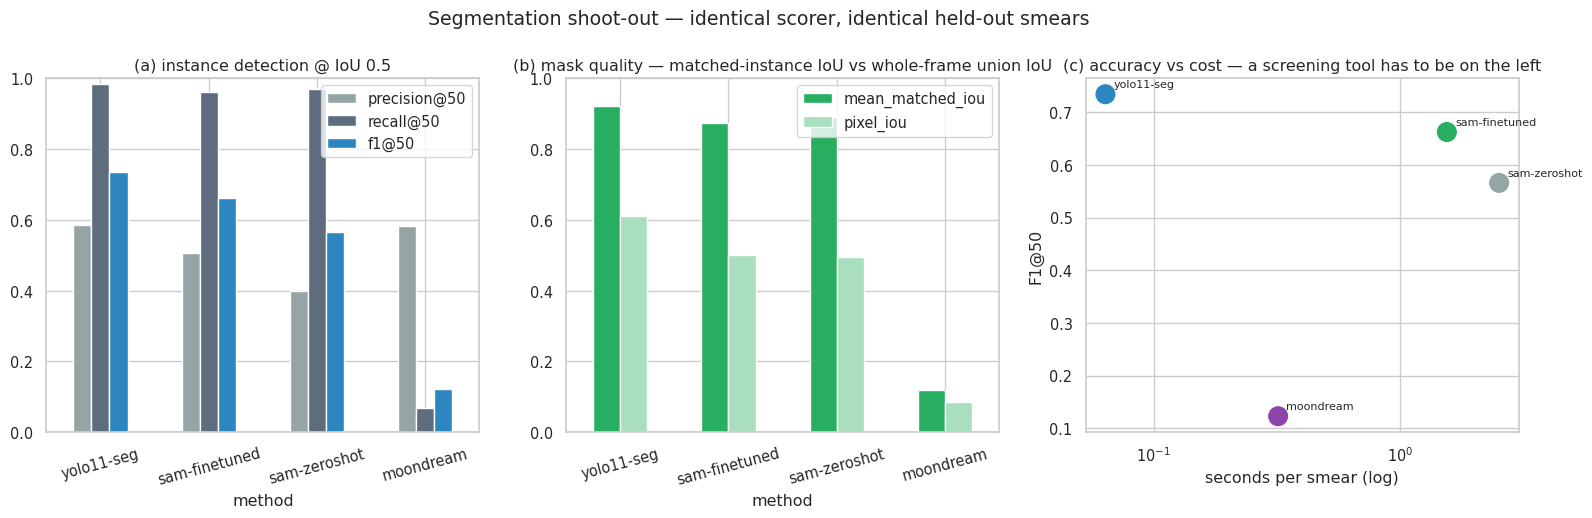

  WINNER: yolo11-seg   F1@50 0.734 | recall 0.983 | precision 0.586 | 0.06 s/smear
  runner-up: sam-finetuned  F1@50 0.662 (+0.072)
  ranking : yolo11-seg > sam-finetuned > sam-zeroshot > moondream
  Stage 2 can never see the 1.7% of real cells this segmenter
  misses, and will classify the 41.4% of its detections that
  have no real cell behind them. That is the ceiling notebook 09 turns into a number.

  caveats carried forward:
   - moondream-boxlevel: no confidence scores, AP not meaningful
   - moondream-boxlevel: adapted by prompt/geometry only, weights untouched
   - moondream: no confidence scores, AP not meaningful
   - moondream: masks are ellipses fitted to boxes, not predicted masks
   - moondream: adapted by prompt/geometry only, weights untouched


In [17]:
race = comp[~comp.exclude_from_shootout].reset_index(drop=True)
order = race.sort_values(['f1@50', 'mask_ap50_95'], ascending=False)
WINNER = order.iloc[0].method
cols = [METHOD_CLR.get(m, '#7F8C8D') for m in race.method]

fig, ax = plt.subplots(1, 3, figsize=(19, 4.6))
race.set_index('method')[['precision@50', 'recall@50', 'f1@50']].plot(
    kind='bar', ax=ax[0], color=['#95A5A6', '#5D6D7E', '#2E86C1'])
ax[0].set_title('(a) instance detection @ IoU 0.5')
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis='x', rotation=15)

race.set_index('method')[['mean_matched_iou', 'pixel_iou']].plot(
    kind='bar', ax=ax[1], color=['#27AE60', '#A9DFBF'])
ax[1].set_title('(b) mask quality — matched-instance IoU vs whole-frame union IoU')
ax[1].set_ylim(0, 1)
ax[1].tick_params(axis='x', rotation=15)

ax[2].scatter(race.sec_per_smear, race['f1@50'], s=180, c=cols, zorder=3)
for name, x, y in zip(race.method, race.sec_per_smear, race['f1@50']):
    ax[2].annotate(name, (x, y), fontsize=8, xytext=(6, 5), textcoords='offset points')
ax[2].set_xscale('log')
ax[2].set_xlabel('seconds per smear (log)')
ax[2].set_ylabel('F1@50')
ax[2].set_title('(c) accuracy vs cost — a screening tool has to be on the left')
fig.suptitle('Segmentation shoot-out — identical scorer, identical held-out smears', y=1.03)
savefig(fig, 'seg_comparison.png')
plt.show()

w = order.iloc[0]
runner = order.iloc[1] if len(order) > 1 else None
json.dump({'winner': WINNER, 'f1@50': float(w['f1@50']),
           'mask_ap50_95': float(w.mask_ap50_95) if w.scores_available else None,
           'sec_per_smear': float(w.sec_per_smear),
           'ranking': order.method.tolist(),
           'chosen_on': 'F1@IoU0.5, tiebreak mask AP@50-95',
           'tier': TIER, 'gpu': GPU, 'timestamp': time.strftime('%Y-%m-%d %H:%M')},
          open(os.path.join(BENCH, 'seg_winner.json'), 'w'), indent=2)
save_state(seg_winner=WINNER)

print('=' * 78)
print(f'  WINNER: {WINNER}   F1@50 {w["f1@50"]:.3f} | recall {w["recall@50"]:.3f} | '
      f'precision {w["precision@50"]:.3f} | {w.sec_per_smear:.2f} s/smear')
if runner is not None:
    print(f'  runner-up: {runner.method}  F1@50 {runner["f1@50"]:.3f} '
          f'({w["f1@50"] - runner["f1@50"]:+.3f})')
print(f'  ranking : {" > ".join(order.method.tolist())}')
print('=' * 78)
print(f'  Stage 2 can never see the {(1 - w["recall@50"]) * 100:.1f}% of real cells this segmenter\n'
      f'  misses, and will classify the {(1 - w["precision@50"]) * 100:.1f}% of its detections that\n'
      '  have no real cell behind them. That is the ceiling notebook 09 turns into a number.')
print('\n  caveats carried forward:')
for r in runs:
    if not r.get('scores_available', True):
        print(f"   - {r['method']}: no confidence scores, AP not meaningful")
    if r.get('mask_source', '').startswith('inscribed'):
        print(f"   - {r['method']}: masks are ellipses fitted to boxes, not predicted masks")
    if 'no gradient fine-tune' in str(r.get('adaptation', '')):
        print(f"   - {r['method']}: adapted by prompt/geometry only, weights untouched")
if len(set(r['tier'] for r in runs)) > 1:
    print('   - !! rows were produced on DIFFERENT GPU tiers '
          f"({set(r['tier'] for r in runs)}) -- re-run them on one tier before quoting this table")

In [18]:
# ═════════════════════════════════════════════════════════════════════════════
#  CHECKPOINT  ·  identical in every notebook of the series
#
#  Appends one record per run to  runs_two_stage/checkpoints.json  -- the single
#  file that answers "which stages have actually been run, on what hardware, how
#  long did they take, what did they write to disk, and what did they score?".
#  Re-running a stage APPENDS; nothing is overwritten, so the file is the run
#  history of the whole pipeline rather than a snapshot of the last run.
# ═════════════════════════════════════════════════════════════════════════════
CKPT_LOG = os.path.join(CFG['runs_dir'], 'checkpoints.json')


def _ckpt_art(p):
    '''one artefact -> exists / size / mtime. Directories are summarised, not listed.'''
    p = str(p)
    if not os.path.exists(p):
        return {'path': p, 'exists': False}
    if os.path.isdir(p):
        fs = [os.path.join(r, f) for r, _, ns in os.walk(p) for f in ns]
        mt = max([os.path.getmtime(f) for f in fs] or [os.path.getmtime(p)])
        return {'path': p, 'exists': True, 'kind': 'dir', 'files': len(fs),
                'mb': round(sum(os.path.getsize(f) for f in fs) / 2 ** 20, 2),
                'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(mt))}
    return {'path': p, 'exists': True, 'kind': 'file',
            'mb': round(os.path.getsize(p) / 2 ** 20, 3),
            'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(os.path.getmtime(p)))}


def _ckpt_val(v):
    '''keep the log json-safe: numbers stay numbers, NaN/inf become null, the rest becomes text'''
    if v is None or isinstance(v, (bool, str)):
        return v
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    return None if (math.isnan(f) or math.isinf(f)) else round(f, 6)


def _ckpt_minutes():
    '''wall-clock minutes this kernel has been alive = how long the run took, near enough'''
    try:
        import psutil
        return round((time.time() - psutil.Process(os.getpid()).create_time()) / 60, 2)
    except Exception:
        return None


def checkpoint(nb, produced=None, metrics=None, status='ok', notes=''):
    '''record that `nb` finished. `produced` = {label: path}; a falsy path is skipped,
    which is how the optional artefacts (a run dir that was not recreated, a table only
    one branch writes) stay out of the missing list.'''
    arts = {k: _ckpt_art(v) for k, v in (produced or {}).items() if v}
    missing = sorted(k for k, a in arts.items() if not a['exists'])
    rec = {'nb': nb,
           'status': 'MISSING ARTEFACTS' if missing else status,
           'finished': time.strftime('%Y-%m-%d %H:%M:%S'),
           'minutes': _ckpt_minutes(),
           'platform': PLATFORM, 'tier': TIER, 'gpu': GPU, 'vram_gb': round(VRAM, 1),
           'torch': torch.__version__, 'seed': SEED,
           'slurm_job': os.environ.get('SLURM_JOB_ID', ''),
           'runs_dir': CFG['runs_dir'],
           'metrics': {k: _ckpt_val(v) for k, v in (metrics or {}).items()},
           'artefacts': arts, 'missing': missing, 'notes': notes,
           'state_keys': sorted(read_state())}

    log = []
    if os.path.exists(CKPT_LOG):
        try:
            log = [r for r in json.load(open(CKPT_LOG)) if isinstance(r, dict)]
        except Exception:
            shutil.copy(CKPT_LOG, CKPT_LOG + '.corrupt')
            print(f'!! {CKPT_LOG} was unreadable -- copied to .corrupt, starting a new log')
    log.append(rec)
    tmp = f'{CKPT_LOG}.{os.getpid()}.tmp'          # atomic: two stages can finish at once
    json.dump(log, open(tmp, 'w'), indent=2, default=str)
    os.replace(tmp, CKPT_LOG)

    print('\n' + '=' * 78)
    print(f'  CHECKPOINT  {nb}   [{rec["status"]}]'
          + (f'   {rec["minutes"]:.1f} min' if rec['minutes'] else ''))
    print(f'  -> {CKPT_LOG}   ({len(log)} records)')
    print('=' * 78)
    for k, a in arts.items():
        print(f'  {"ok  " if a["exists"] else "MISS"}  {k:<20s} {a.get("mb", 0):>9.2f} MB  '
              f'{a["path"]}')
    for k, v in rec['metrics'].items():
        print(f'  metric  {k:<20s} {v}')
    last = {r['nb']: r for r in log}              # one row per stage, most recent run wins
    print(f'\n  stages recorded in this runs_dir ({len(last)}):')
    for k in sorted(last):
        r = last[k]
        print(f'   {"ok" if r["status"] == "ok" else "!!"}  {k:<40s} {r["finished"]}  '
              f'tier {r.get("tier", "?")}')
    return rec

checkpoint(
    '04_segmentation_comparison',
    produced={'winner': os.path.join(BENCH, 'seg_winner.json'),
              'table': os.path.join(TAB, 'segmentation_comparison.csv'),
              'figure': os.path.join(FIG, 'seg_comparison.png')},
    metrics={'winner': WINNER, 'f1@50': w['f1@50'],
             'precision@50': w['precision@50'], 'recall@50': w['recall@50'],
             'sec_per_smear': w['sec_per_smear'],
             'candidates': len(race),
             'ranking': ' > '.join(order.method.tolist()),
             'tiers_mixed': len(set(r['tier'] for r in runs)) > 1},
    notes='stage-1 winner -- 14 and 15 read this file, not a variable')


  CHECKPOINT  04_segmentation_comparison   [ok]   5.3 min
  -> /home/bahajao/runs_two_stage/checkpoints.json   (5 records)
  ok    winner                    0.00 MB  /home/bahajao/runs_two_stage/seg_bench/seg_winner.json
  ok    table                     0.00 MB  /home/bahajao/runs_two_stage/tables/segmentation_comparison.csv
  ok    figure                    0.12 MB  /home/bahajao/runs_two_stage/figures/seg_comparison.png
  metric  winner               yolo11-seg
  metric  f1@50                0.733974
  metric  precision@50         0.585678
  metric  recall@50            0.982833
  metric  sec_per_smear        0.063626
  metric  candidates           4.0
  metric  ranking              yolo11-seg > sam-finetuned > sam-zeroshot > moondream
  metric  tiers_mixed          False

  stages recorded in this runs_dir (5):
   ok  00_setup_and_data                        2026-08-03 09:55:00  tier a100
   ok  01_segmentation_yolo                     2026-08-03 10:12:08  tier a100
   ok  02_segm

{'nb': '04_segmentation_comparison',
 'status': 'ok',
 'finished': '2026-08-03 10:28:48',
 'minutes': 5.29,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'vram_gb': 79.3,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49919771',
 'runs_dir': '/home/bahajao/runs_two_stage',
 'metrics': {'winner': 'yolo11-seg',
  'f1@50': 0.733974,
  'precision@50': 0.585678,
  'recall@50': 0.982833,
  'sec_per_smear': 0.063626,
  'candidates': 4.0,
  'ranking': 'yolo11-seg > sam-finetuned > sam-zeroshot > moondream',
  'tiers_mixed': False},
 'artefacts': {'winner': {'path': '/home/bahajao/runs_two_stage/seg_bench/seg_winner.json',
   'exists': True,
   'kind': 'file',
   'mb': 0.0,
   'modified': '2026-08-03 10:28'},
  'table': {'path': '/home/bahajao/runs_two_stage/tables/segmentation_comparison.csv',
   'exists': True,
   'kind': 'file',
   'mb': 0.001,
   'modified': '2026-08-03 10:28'},
  'figure': {'path': '/home/bahajao/runs_two_stage/figures/seg_comparison.png',
   'exi